In [1]:
pip install jpype1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path

import jpype
from jpype import JClass, getDefaultJVMPath

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from functools import lru_cache

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
import json


[nltk_data] Downloading package stopwords to C:\Users\Laptop
[nltk_data]     Dunyası\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Laptop
[nltk_data]     Dunyası\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Laptop
[nltk_data]     Dunyası\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
df1 = pd.read_excel("Datasets/e-ticaret_yorumlari_temizlenmis.xlsx")
df2 = pd.read_csv("Datasets/e-ticaret_urun_yorumlari.csv", sep=";", encoding="utf-8-sig")
df3 = pd.read_csv("Datasets/magaza_yorumlari_duygu_analizi.csv",
                  encoding="utf-16", delimiter=",", on_bad_lines="skip", quotechar='"')
df4 = pd.read_excel("Datasets/cluster_base_undersampling_veri_seti.xlsx")

print("df1:")
print(df1.head(), "\n")

print("df2:")
print(df2.head(), "\n")

print("df3:")
print(df3.head(), "\n")

print("df4:")
print(df4.head(), "\n")

df1:
                                            yorumlar    duygu
0  ekran cikti acilmiyor bilgisayar bozuk gonderd...  negatif
1                 telefon 2 ay ayda bozuldu maalesef  negatif
2                giydiğimde sorulan gömleğim s beden  pozitif
3  öncelikle ürün yorumlara bakarak numara büyük ...  pozitif
4          cok rahat sportif tatlı ayakkabı kendi no  pozitif 

df2:
                                               Metin  Durum
0                              evet anlatıldığı gibi      1
1  Daha öncede almıştım bu cihazdan ense ve sakal...      1
2  Ürün gayet başarılı sakal kesmede başlık sayıs...      1
3  Daha öncede aynısını almıştım çok güzel ve kal...      1
4  Erkek kuaförüyüm ense ve sıfır sakal traşı içi...      1 

df3:
                                               Görüş     Durum
0  ses kalitesi ve ergonomisi rezalet, sony olduğ...   Olumsuz
1                         hizli teslimat tesekkürler  Tarafsız
2  ses olayı süper....gece çalıştır sıkıntı yok.....    Olum

In [4]:
df2 = df2.rename(columns={"Metin":"yorumlar", "Durum":"duygu"})
map2 = {1:"pozitif", 0:"negatif", 2:"notr"}
df2["duygu"] = df2["duygu"].map(map2)

df3 = df3.rename(columns={"Görüş":"yorumlar", "Durum":"duygu"})
map3 = {"Olumlu":"pozitif", "Olumsuz":"negatif", "Tarafsız":"notr"}
df3["duygu"] = df3["duygu"].map(map3)

df_all = pd.concat([df1[["yorumlar","duygu"]],
                    df2[["yorumlar","duygu"]],
                    df3[["yorumlar","duygu"]],
                    df4[["yorumlar","duygu"]]], ignore_index=True)

df_all = df_all.dropna(subset=["yorumlar","duygu"])
df_all["yorumlar"] = df_all["yorumlar"].astype(str).str.strip()
df_all = df_all[df_all["yorumlar"].str.len() >= 2]
df_all = df_all.drop_duplicates(subset=["yorumlar"])

valid = {"pozitif","negatif","notr"}
df_all = df_all[df_all["duygu"].isin(valid)]

print("Toplam dağılım:")
print(df_all["duygu"].value_counts())

def sample_with_max_neutral(df, k=10_000):
    pos = df[df.duygu=="pozitif"].sample(n=min(k, (df.duygu=="pozitif").sum()), random_state=42)
    neg = df[df.duygu=="negatif"].sample(n=min(k, (df.duygu=="negatif").sum()), random_state=42)
    neu = df[df.duygu=="notr"]
    return pd.concat([pos, neg, neu], ignore_index=True).sample(frac=1, random_state=42)

df_final = sample_with_max_neutral(df_all, k=10_000)

print("Son seçim dağılımı:")
print(df_final["duygu"].value_counts())

df_final.to_csv("final_dengeli_yorumlar.csv", index=False, encoding="utf-8-sig")

Toplam dağılım:
duygu
pozitif    66649
negatif    21514
notr        5060
Name: count, dtype: int64
Son seçim dağılımı:
duygu
pozitif    10000
negatif    10000
notr        5060
Name: count, dtype: int64


In [5]:
df = pd.read_csv("Datasets/final_dengeli_yorumlar.csv", encoding="utf-8-sig")
print(df.shape)
print(df.head())

(25060, 2)
                                            yorumlar    duygu
0                 Fiyatına göre gayet güzel bir ürün  pozitif
1  sıfır kutusunda sorunsuz fiyatı ram 3gb olduğu...  pozitif
2  makinanın heryeri yapışkanlı gibi tuttuğum yer...     notr
3                şahane telefon satıcıya selam olsun  pozitif
4               kalitesiz bir ürün tavsiye etmiyorum  negatif


In [6]:
print(df.isnull().sum())

yorumlar    0
duygu       0
dtype: int64


In [7]:
class_counts = df['duygu'].value_counts()
print(class_counts)

duygu
pozitif    10000
negatif    10000
notr        5060
Name: count, dtype: int64


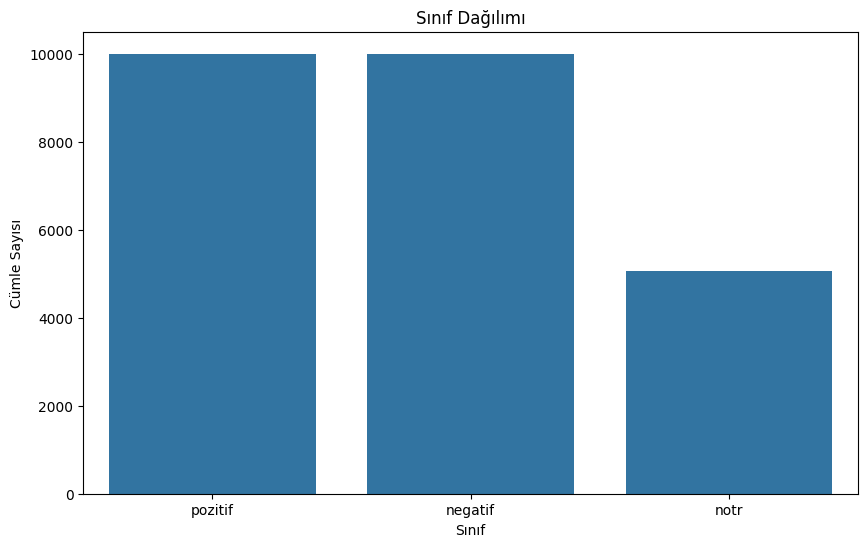

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Sınıf Dağılımı')
plt.xlabel('Sınıf')
plt.ylabel('Cümle Sayısı')
plt.show()

In [9]:
ZEMBEREK_PATH = "zemberek-full.jar"
JVM_PATH = r"C:\Users\Laptop Dunyası\Downloads\eclipse-java-2024-06-R-win32-x86_64\eclipse\plugins\org.eclipse.justj.openjdk.hotspot.jre.full.win32.x86_64_21.0.3.v20240426-1530\jre\bin\server\jvm.dll"  # Burayı kendi yoluna göre düzelt

if not jpype.isJVMStarted():
    jpype.startJVM(JVM_PATH, "-ea", f"-Djava.class.path={ZEMBEREK_PATH}")
else:
    print("JVM zaten çalışıyor.")

TurkishMorphology   = JClass("zemberek.morphology.TurkishMorphology")
TurkishTokenizer    = JClass("zemberek.tokenization.TurkishTokenizer")
TurkishSpellChecker = JClass("zemberek.normalization.TurkishSpellChecker")

morphology    = TurkishMorphology.createWithDefaults()
tokenizer     = TurkishTokenizer.DEFAULT
spell_checker = TurkishSpellChecker(morphology)

print("Zemberek hazır")

Zemberek hazır


In [10]:
stop_words = set(stopwords.words('turkish'))

def clean_text(t: str) -> str:
    t = re.sub(r"<[^>]+>", " ", str(t))
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"[^0-9a-zçğıöşüA-ZÇĞİÖŞÜ\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t.lower()

_ALNUM_TR  = re.compile(r"^[0-9a-zçğıöşüA-ZÇĞİÖŞÜ]+$")
ASCII_ONLY = re.compile(r"^[a-z0-9]+$")

def zemberek_tokenize(text: str):
    toks = [str(x) for x in tokenizer.tokenizeToStrings(text)]
    return [w for w in toks if _ALNUM_TR.match(w)]

_DIACRITIC_MAP = {"c":"ç","g":"ğ","i":"ı","o":"ö","s":"ş","u":"ü"}

@lru_cache(maxsize=100_000)
def is_known(w: str) -> bool:
    ana = morphology.analyzeAndDisambiguate(w).bestAnalysis()
    return not (ana.isEmpty() or ana.get(0).isUnknown())

@lru_cache(maxsize=100_000)
def correct_token(w: str) -> str:
    w = w.lower()
    if len(w) <= 1:
        return w
    if spell_checker.check(w) or is_known(w):
        return w
    sugs = spell_checker.suggestForWord(w)
    if not sugs.isEmpty():
        cand = str(sugs.get(0)).lower()
        if spell_checker.check(cand) or is_known(cand):
            return cand
    if ASCII_ONLY.match(w):
        cand1 = {w[:i] + _DIACRITIC_MAP[ch] + w[i+1:] for i, ch in enumerate(w) if ch in _DIACRITIC_MAP}
        for c in cand1:
            if is_known(c): return c
        cand2 = {c[:i] + _DIACRITIC_MAP[ch] + c[i+1:] for c in cand1 for i, ch in enumerate(c) if ch in _DIACRITIC_MAP}
        for c in cand2:
            if is_known(c): return c
    return w

NEGATORS = {"değil","degil","yok","hiç","hic","asla"}

def add_neg_prefix(tokens, window=1):
    if not APPLY_NEGATION: return tokens
    out=[]; i=0
    while i < len(tokens):
        if tokens[i] in NEGATORS:
            out.append("not_"+tokens[i])
            if i+1 < len(tokens): out.append("not_"+tokens[i+1])
            i += 2
        else:
            out.append(tokens[i]); i += 1
    return out

EXTRA_STOPS = {
    "urun","ürün","urunu","ürünü","urunü","üründe",
    "orjinal","orijinal",
    "tesekkur","teşekkür","tesekkürler","teşekkürler",
    "gibi","falan","filan","vesaire","vs",
    "ayrica","ancak","lakin","zaten","yani"
}

stop_all = stop_words | EXTRA_STOPS

APPLY_NEGATION  = True
APPLY_STOPWORDS = True

def filter_stopwords(tokens):
    return [w for w in tokens if w not in stop_all] if APPLY_STOPWORDS else tokens

def preprocess_basic(text: str) -> str:
    s    = clean_text(text)
    toks = zemberek_tokenize(s)
    toks = [correct_token(t) for t in toks]
    toks = add_neg_prefix(toks, window=1)
    toks = filter_stopwords(toks)
    return " ".join(toks)

In [11]:
is_known.cache_clear()
correct_token.cache_clear()

df["yorumlar"] = df["yorumlar"].astype(str).apply(preprocess_basic)
display(df[["yorumlar","duygu"]].head(10))

,yorumlar,duygu
0,fiyatına göre gayet güzel bir,pozitif
1,sıfır kutusunda sorunsuz fiyatı ram gb olduğu ...,pozitif
2,makinanın heryeri yapışkanlı tuttuğum yer yapı...,notr
3,şahane telefon satıcıya selam olsun,pozitif
4,kalitesiz bir tavsiye etmiyorum,negatif
5,fiyatı bence uygun uzun süre kullanıma uygun n...,negatif
6,tam bir fiyat performans tarak çeşidi fazla ol...,notr
7,not_yok not_ki ortada beğeneyim,negatif
8,büyük beden alınması tavsiye ederim,pozitif
9,iyiki almışım kaliteli tam istediğim ayakkabı ...,pozitif


In [12]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

X_text = df["yorumlar"].tolist()

label_map = {'negatif': 0, 'notr': 1, 'pozitif': 2}
df['duygu_numeric'] = df['duygu'].map(label_map)
y = df["duygu_numeric"].astype("int32").values

X_train, X_val, y_train, y_val = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y
)

MAX_VOCAB = 10000
MAX_LEN   = 100

tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>", filters="", lower=True)
tok.fit_on_texts(X_train)

def to_padded(texts, tok, maxlen):
    seqs = tok.texts_to_sequences(texts)
    oov_id = tok.word_index.get("<OOV>", 1)
    seqs = [s if len(s) else [oov_id] for s in seqs]
    return pad_sequences(seqs, maxlen=maxlen, padding="post", truncating="post")

Xtr = to_padded(X_train, tok, MAX_LEN)
Xva = to_padded(X_val, tok, MAX_LEN)

y_train = np.asarray(y_train, dtype="int32").ravel()
y_val   = np.asarray(y_val,   dtype="int32").ravel()

VOCAB_SIZE = min(MAX_VOCAB, len(tok.word_index) + 1)

def bilstm_model(vocab_size, maxlen, num_classes=3,
                       emb_dim=128, lstm_units=128, dr=0.7, lr=5e-4):
    inp = layers.Input(shape=(maxlen,), dtype="int32")
    x = layers.Embedding(vocab_size, emb_dim, mask_zero=False)(inp)
    x = layers.Bidirectional(
            layers.LSTM(lstm_units, dropout=0.7, recurrent_dropout=0.2,
                        return_sequences=False)
        )(x)
    x = layers.Dropout(dr)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dr)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizers.Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model

In [13]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
cw = dict(enumerate(class_weights))
print("Class Weights:", cw)

cb = [
    callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-6,verbose=1
    ),
    callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,verbose=1
    )
]

model = bilstm_model(VOCAB_SIZE, MAX_LEN, num_classes=3,emb_dim=128, lstm_units=128,dr=0.3, lr=5e-4)
model.summary()

history = model.fit(
    Xtr, y_train,
    validation_data=(Xva, y_val),
    epochs=12,
    batch_size=128,
    class_weight=cw,
    callbacks=cb,
    verbose=1
)

Class Weights: {0: np.float64(0.8353333333333334), 1: np.float64(1.6508563899868247), 2: np.float64(0.8353333333333334)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,451 (6.01 MB)

 Trainable params: 1,576,451 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 105s 568ms/step - accuracy: 0.4953 - loss: 0.9949 - val_accuracy: 0.6850 - val_loss: 0.7700 - learning_rate: 5.0000e-04
Epoch 2/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 545ms/step - accuracy: 0.7083 - loss: 0.7245 - val_accuracy: 0.7249 - val_loss: 0.6709 - learning_rate: 5.0000e-04
Epoch 3/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 91s 581ms/step - accuracy: 0.7496 - loss: 0.6392 - val_accuracy: 0.7227 - val_loss: 0.6710 - learning_rate: 5.0000e-04
Epoch 4/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 92s 588ms/step - accuracy: 0.7806 - loss: 0.5741 - val_accuracy: 0.7251 - val_loss: 0.6704 - learning_rate: 5.0000e-04
Epoch 5/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 540ms/step - accuracy: 0.7977 - loss: 0.5308 - val_accuracy: 0.7273 - val_loss: 0.6851 - learning_rate: 5.0000e-04
Epoch 6/12
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8116 - loss: 0.4954
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 547ms/s

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = y_val
probs = model.predict(Xva, verbose=0)

print("Shape:", probs.shape)

if probs.ndim == 2:
    y_pred_classes = probs.argmax(axis=1)
else:
    y_pred_classes = probs

val_acc = accuracy_score(y_true, y_pred_classes)
print(f"Validation Accuracy (sklearn): {val_acc:.4f}\n")

target_names = ["negatif", "notr", "pozitif"]
print(classification_report(y_true, y_pred_classes, target_names=target_names))
print(confusion_matrix(y_true, y_pred_classes))

print("F1 skor:", f1_score(y_true, y_pred_classes, average="macro"))


Shape: (5012, 3)
Validation Accuracy (sklearn): 0.7251

              precision    recall  f1-score   support

     negatif       0.80      0.71      0.76      2000
        notr       0.49      0.73      0.59      1012
     pozitif       0.85      0.73      0.79      2000

    accuracy                           0.73      5012
   macro avg       0.71      0.73      0.71      5012
weighted avg       0.76      0.73      0.73      5012

[[1430  396  174]
 [ 183  742   87]
 [ 167  371 1462]]
F1 skor: 0.7102190599950965


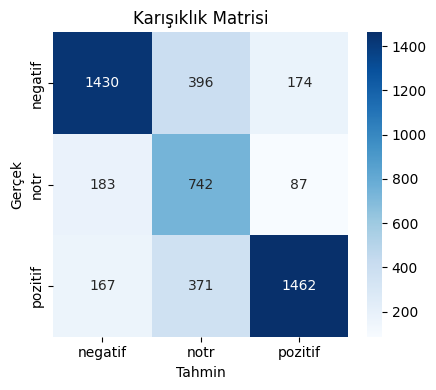

In [15]:
cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(4.5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["negatif","notr","pozitif"],
    yticklabels=["negatif","notr","pozitif"]
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Karışıklık Matrisi")
plt.tight_layout()
plt.show()


In [16]:
id2lbl = {0:"negatif", 1:"notr", 2:"pozitif"}

def predict_text(text, model, tok, maxlen=100):
    text_clean = clean_text(text)
    seq = tok.texts_to_sequences([text_clean])
    if len(seq[0]) == 0:
        seq = [[tok.word_index.get("<OOV>", 1)]]

    pad_seq = pad_sequences(seq, maxlen=maxlen, padding="post", truncating="post")

    probs = model.predict(pad_seq, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = id2lbl[pred_idx]
    confidence = float(probs[pred_idx])

    return pred_label, confidence

examples = [
    "Ürün çok kaliteli, gerçekten memnun kaldım.",
    "Kargo çok geç geldi, paket yırtıktı.",
    "Ürün fiyatı fena değil, idare eder.",
    "Ürün güzel ama fiyatına göre performansı düşük.",
    "Kargo biraz geç geldi ama satıcı çok yardımcı oldu.",
    "Telefonun özellikleri iyi fakat bataryası çabuk bitiyor.",
    "Ürün fena değil, çok iyi de sayılmaz.",
    "Kalitesi düşük ama işimi gördü.",
    "Beklediğim kadar iyi değil ama idare eder.",
    "Ürün şık görünüyor fakat kullanışlı değil.",
    "Fiyatı yüksek ama kalitesi de gerçekten güzel.",
    "Ürün anlatıldığı gibi değil ama iade süreci sorunsuzdu."
    
]

for txt in examples:
    label, conf = predict_text(txt, model, tok, maxlen=MAX_LEN)
    print(f"Metin: {txt}")
    print(f"Tahmin: {label} (güven: {conf:.2f})")
    print("-"*60)

Metin: Ürün çok kaliteli, gerçekten memnun kaldım.
Tahmin: pozitif (güven: 0.84)
------------------------------------------------------------
Metin: Kargo çok geç geldi, paket yırtıktı.
Tahmin: notr (güven: 0.78)
------------------------------------------------------------
Metin: Ürün fiyatı fena değil, idare eder.
Tahmin: notr (güven: 0.94)
------------------------------------------------------------
Metin: Ürün güzel ama fiyatına göre performansı düşük.
Tahmin: notr (güven: 0.72)
------------------------------------------------------------
Metin: Kargo biraz geç geldi ama satıcı çok yardımcı oldu.
Tahmin: notr (güven: 0.88)
------------------------------------------------------------
Metin: Telefonun özellikleri iyi fakat bataryası çabuk bitiyor.
Tahmin: notr (güven: 0.79)
------------------------------------------------------------
Metin: Ürün fena değil, çok iyi de sayılmaz.
Tahmin: notr (güven: 0.93)
------------------------------------------------------------
Metin: Kalitesi düşü

In [17]:
pip install -U nlpaug transformers torch


   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
    --------------------------------------- 0.3/11.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.6 MB 1.9 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/11.6 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.6 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/11.6 MB 2.1 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.6 MB 2.1 MB/s eta 0:00:05
   --------- ------------------------------ 2.6/11.6 MB 2.0 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/11.6 MB 2.1 MB/s eta 0:00:05
   ----------- ---------------------------- 3.4/11.6 MB 2.0 MB/s eta 0:00:05
   ------------- -------------------------- 3.9/11.6 MB 2.1 MB/s eta 0:00:04
   ----------------- ---------------------- 5.0/11.6 MB 2.3 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/11.6 MB 2.4 MB/s eta 0:00:03
   ----------

In [18]:
import nlpaug.augmenter.word as naw

ctx_sub = naw.ContextualWordEmbsAug(
    model_path="dbmdz/bert-base-turkish-cased",
    action="substitute",
    aug_p=0.10,
    device="cpu"
)

ctx_ins = naw.ContextualWordEmbsAug(
    model_path="dbmdz/bert-base-turkish-cased",
    action="insert",
    aug_p=0.08,
    device="cpu"
)

def augment_ctx_once(text, mode="sub"):
    if mode == "sub":
        return ctx_sub.augment(text)
    else:
        return ctx_ins.augment(text)

c:\Users\Laptop Dunyası\OneDrive\Masaüstü\sentiment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following layers were not sharded: bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.self.key.bias, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.query.bias, cls.predictions.bias, cls.predictions.transform.LayerNorm.bias, cls.predictions.transform.LayerNorm.weight, cls.predictions.transform.dense.weight, cls.predictions.decoder.weight, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.output.dense.weight, bert.embeddings.wor

In [19]:
id2lbl = {0: "negatif", 1: "notr", 2: "pozitif"}

def model_label(text, _model=model, _tok=tok):
    cls, _ = predict_text(text, _model, _tok)
    try:
        return id2lbl[int(cls)]
    except (ValueError, KeyError, TypeError):
        return str(cls).lower()

def augment_label_to_target(df, label, target_n, mode_cycle=("sub","ins"), consistency_check=True, seed=42):
    rng = np.random.default_rng(seed)
    cur = df[df["duygu"] == label].copy()
    have = len(cur)
    need = max(0, target_n - have)
    if need == 0:
        return df.copy()

    src = cur.sample(n=min(have, need), replace=(have < need), random_state=seed)["yorumlar"].tolist()

    aug_texts = []
    m = len(mode_cycle)
    for i, s in enumerate(src):
        mode = mode_cycle[i % m]
        try:
            aug = augment_ctx_once(s, mode=mode)
            if isinstance(aug, list):
                aug = aug[0]
            aug_texts.append(aug)
        except Exception:
            continue

    df_aug = pd.DataFrame({"yorumlar": aug_texts[:need], "duygu": label})

    if consistency_check and not df_aug.empty:
        preds = df_aug["yorumlar"].apply(model_label)
        df_aug = df_aug[preds.values == df_aug["duygu"].values]

    out = pd.concat([df, df_aug], ignore_index=True)
    out = out.drop_duplicates(subset=["yorumlar"]).reset_index(drop=True)
    return out

In [20]:
df_bal = df_final.copy()

df_bal = augment_label_to_target(
    df_bal,
    label="notr",
    target_n=10_000,
    mode_cycle=("sub","ins"),
    consistency_check=True,
    seed=42
)

print("Sınıf sayımları (artırma sonrası):")
print(df_bal["duygu"].value_counts())

Sınıf sayımları (artırma sonrası):
duygu
pozitif    10000
negatif    10000
notr        9168
Name: count, dtype: int64


In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    df_bal["yorumlar"],
    df_bal["duygu"],
    test_size=0.2,
    random_state=42,
    stratify=df_bal["duygu"]
)

train_df = pd.DataFrame({"yorumlar": X_train, "duygu": y_train})
val_df   = pd.DataFrame({"yorumlar": X_val,   "duygu": y_val})

print("Train dağılımı:")
print(train_df["duygu"].value_counts())

print("\nVal dağılımı:")
print(val_df["duygu"].value_counts())

Train dağılımı:
duygu
negatif    8000
pozitif    8000
notr       7334
Name: count, dtype: int64

Val dağılımı:
duygu
pozitif    2000
negatif    2000
notr       1834
Name: count, dtype: int64


In [22]:
MAX_VOCAB = 20000
MAX_LEN   = 100

tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok.fit_on_texts(train_df["yorumlar"])

X_train_seq = tok.texts_to_sequences(train_df["yorumlar"])
X_val_seq   = tok.texts_to_sequences(val_df["yorumlar"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")

In [23]:
le = LabelEncoder()
y_train_enc = le.fit_transform(train_df["duygu"])
y_val_enc   = le.transform(val_df["duygu"])

y_train_cat = to_categorical(y_train_enc)
y_val_cat   = to_categorical(y_val_enc)

In [24]:
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

c:\Users\Laptop Dunyası\OneDrive\Masaüstü\sentiment_analysis\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
cb = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=128,
    callbacks=cb,
    verbose=1
)

Epoch 1/30


183/183 ━━━━━━━━━━━━━━━━━━━━ 150s 773ms/step - accuracy: 0.3398 - loss: 1.0990 - val_accuracy: 0.3433 - val_loss: 1.0984 - learning_rate: 0.0010
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 147s 805ms/step - accuracy: 0.3461 - loss: 1.0982 - val_accuracy: 0.3428 - val_loss: 1.0985 - learning_rate: 0.0010
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 143s 780ms/step - accuracy: 0.3428 - loss: 1.0983 - val_accuracy: 0.3426 - val_loss: 1.0981 - learning_rate: 0.0010
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 126s 688ms/step - accuracy: 0.3412 - loss: 1.1019 - val_accuracy: 0.3445 - val_loss: 1.0972 - learning_rate: 0.0010
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 125s 685ms/step - accuracy: 0.3773 - loss: 1.0831 - val_accuracy: 0.4753 - val_loss: 1.0196 - learning_rate: 0.0010
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 128s 701ms/step - accuracy: 0.5183 - loss: 0.9794 - val_accuracy: 0.5362 - val_loss: 0.9462 - learning_rate: 0.0010
Epoch 7/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 126s 688ms/step - accuracy: 0.5988 

In [26]:
y_val_pred_probs = model.predict(X_val_pad, verbose=0)
y_val_pred = y_val_pred_probs.argmax(axis=1)

print("Classification Report (Validation):")
print(classification_report(y_val_enc, y_val_pred, target_names=le.classes_))

f1_macro = f1_score(y_val_enc, y_val_pred, average="macro")
print(f"Macro F1: {f1_macro:.4f}")

Classification Report (Validation):
              precision    recall  f1-score   support

     negatif       0.72      0.77      0.74      2000
        notr       0.82      0.66      0.73      1834
     pozitif       0.76      0.84      0.80      2000

    accuracy                           0.76      5834
   macro avg       0.76      0.76      0.76      5834
weighted avg       0.76      0.76      0.76      5834

Macro F1: 0.7564


In [27]:
def predict_text(text, model=model, tok=tok, maxlen=100):
    seq = tok.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=maxlen, padding="post", truncating="post")
    probs = model.predict(pad, verbose=0)[0]
    cls = probs.argmax()
    return le.classes_[cls], probs

examples = [
    "Ürün gerçekten harika, çok memnun kaldım.",
    "Kargo çok geç geldi ve paket yırtıktı.",
    "Ürün fena değil, idare eder.",
    "Telefonun özellikleri iyi ama bataryası çabuk bitiyor.",
    "Ürün güzel ama fiyatına göre performansı düşük.",
    "Kargo biraz geç geldi ama satıcı çok yardımcı oldu.",
    "Sevdim ürünü, tekrar alırım.",
    "Tavsiye ederim.",
    "Berbat"
]

for ex in examples:
    label, probs = predict_text(ex)
    print(f"Metin: {ex}")
    print(f"Tahmin: {label}, Olasılıklar: {probs}\n")

Metin: Ürün gerçekten harika, çok memnun kaldım.
Tahmin: pozitif, Olasılıklar: [0.03396097 0.01233477 0.95370436]

Metin: Kargo çok geç geldi ve paket yırtıktı.
Tahmin: negatif, Olasılıklar: [0.8968815  0.04862601 0.05449256]

Metin: Ürün fena değil, idare eder.
Tahmin: notr, Olasılıklar: [0.00664121 0.991231   0.00212779]

Metin: Telefonun özellikleri iyi ama bataryası çabuk bitiyor.
Tahmin: notr, Olasılıklar: [0.00797561 0.98935527 0.00266907]

Metin: Ürün güzel ama fiyatına göre performansı düşük.
Tahmin: notr, Olasılıklar: [0.00675186 0.990647   0.00260104]

Metin: Kargo biraz geç geldi ama satıcı çok yardımcı oldu.
Tahmin: notr, Olasılıklar: [0.02001332 0.9739255  0.0060612 ]

Metin: Sevdim ürünü, tekrar alırım.
Tahmin: pozitif, Olasılıklar: [0.30779183 0.06745581 0.62475234]

Metin: Tavsiye ederim.
Tahmin: pozitif, Olasılıklar: [0.0642937  0.04403212 0.8916742 ]

Metin: Berbat
Tahmin: negatif, Olasılıklar: [0.8740066  0.07970319 0.0462902 ]



In [ ]:
from pathlib import Path

current_dir = Path .cwd() / "Models"
current_dir.mkdir(parents=True, exist_ok=True)

save_path = current_dir / "bilstm_model.keras"
model.save(save_path)

print(f"BiLSTM modeli kaydedildi: {save_path}")


BiLSTM modeli kaydedildi: c:\Users\Laptop Dunyası\OneDrive\Masaüstü\sentiment_analysis\Models\bilstmm_model.keras
